# 📉 Assignment 1: The Vanishing Gradient Problem

The **vanishing gradient problem** occurs in deep artificial neural networks when the error gradients become exponentially smaller as they propagate backward from the output layer to the earlier hidden layers. This phenomenon prevents the deeper layers from updating their weights effectively, causing the network to stagnate.

It is most commonly observed when using the **Sigmoid** or **Tanh** activation functions, as their derivatives are extremely small (max $0.25$ for Sigmoid). When stacked across many layers, multiplying these tiny derivatives shrinks the gradient toward zero.

In this notebook, we intentionally build a very deep, 6-layer FeedForward network using Sigmoid activations to mathematically demonstrate and visualize this failure. We will observe the network using two different loss architectures:
1. **Standard CrossEntropy Loss** (The mathematically preferred approach for classification)
2. **Mean Squared Error (MSE) with One-Hot Encoding** (A demonstrative approach illustrating weak loss signaling)

In [108]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import torch.nn.functional as F
import warnings; warnings.filterwarnings("ignore")

csv_path = "Iris.csv"
NUM_EPOCHS = 50

## Part 1: Standard CrossEntropy Loss
CrossEntropy is the standard loss function for multi-class classification. It applies a mathematical logarithm that aggressively penalizes confident wrong predictions, ensuring a strong initial error signal. However, even with a strong signal, we will see if the depth of the network still causes the gradient to vanish.

### 1. Data - Load and Preprocess Dataset
**Description:** 
This cell fetches the classical **Iris** dataset. Neural networks are highly sensitive to unscaled numerical features, so we apply **Z-score Normalization (`StandardScaler`)** to center the inputs around mean $0$ with a standard deviation of $1$. The target string labels (e.g., `Iris-setosa`) are mapped to integer classes (`0, 1, 2`) using `LabelEncoder`, which is the format `CrossEntropyLoss` requires. Finally, the data is split into an 80/20 train-test partition.

In [109]:
df = pd.read_csv(csv_path)

X = df.drop(["Id", "Species"], axis=1).values
y = df["Species"].values

# Z-score Normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

### 2. Model - Initialize Network Architecture
**Description:** 
Here, we construct `DeepNet`, a densely connected FeedForward Neural Network. It contains 6 deep hidden layers with sizes `[4 -> 256 -> 256 -> 128 -> 128 -> 64 -> 32]`. 

Crucially, every hidden layer uses the `torch.sigmoid()` activation function. By forcing the data to continuously compress through these sigmoids across 6 deep layers, we deliberately set up the architectural trap necessary to trigger the vanishing gradient problem.

In [110]:
class DeepNet(nn.Module):
    def __init__(self):
        super(DeepNet, self).__init__()
        sizes = [4, 256, 256, 128, 128, 64, 32]
        self.hidden_layers = nn.ModuleList([
            nn.Linear(sizes[i], sizes[i+1]) for i in range(len(sizes)-1)
        ])
        self.output_layer = nn.Linear(32, 3)
        
    def forward(self, x):
        for layer in self.hidden_layers:
            x = torch.sigmoid(layer(x))
        return self.output_layer(x)

model = DeepNet()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 3. Training Algorithm - Execute Backpropagation
### 4. Loss Function and Activation Function - Describe and Visualize Loss
**Description:** 
The training algorithm loops for `NUM_EPOCHS` epochs using the `Adam` optimizer. During the backward pass (`loss.backward()`), we calculate the `CrossEntropyLoss` and hook into PyTorch's computational graph to extract the **absolute mean gradient magnitude** of the weights in every single hidden layer. This data is saved into `history_ce` so we can visualize exactly how the signal decays layer by layer. A plot of the final loss convergence over time is displayed at the end.

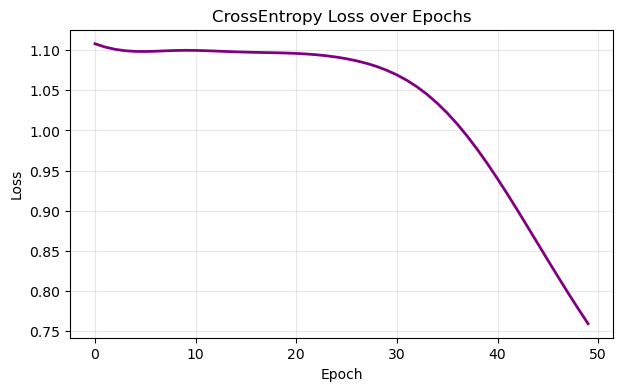

In [111]:
criterion = nn.CrossEntropyLoss()
history_ce = [[] for _ in model.hidden_layers]
loss_history_ce = []

for epoch in range(1, NUM_EPOCHS + 1):
    optimizer.zero_grad()
    
    # Forward Pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    # Backward Pass (calculates gradients)
    loss.backward()
    
    # Collect absolute mean gradient for each layer
    for i, layer in enumerate(model.hidden_layers):
        history_ce[i].append(layer.weight.grad.abs().mean().item())

    optimizer.step()
    loss_history_ce.append(loss.item())

# Visualize Loss
plt.figure(figsize=(7, 4))
plt.plot(loss_history_ce, color="purple", linewidth=2)
plt.title("CrossEntropy Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

### 5. Visualize the Vanishing Gradient
**Description:** 
This graph plots the average gradient magnitude per epoch, separated by layer. Look closely at the differences between Layer 1 (the deepest layer, furthest from the output) and Layer 6 (the layer closest to the output). You will visually confirm that the gradients for Layer 1 and 2 remain almost perfectly flat near zero, mathematically proving that they are not learning.

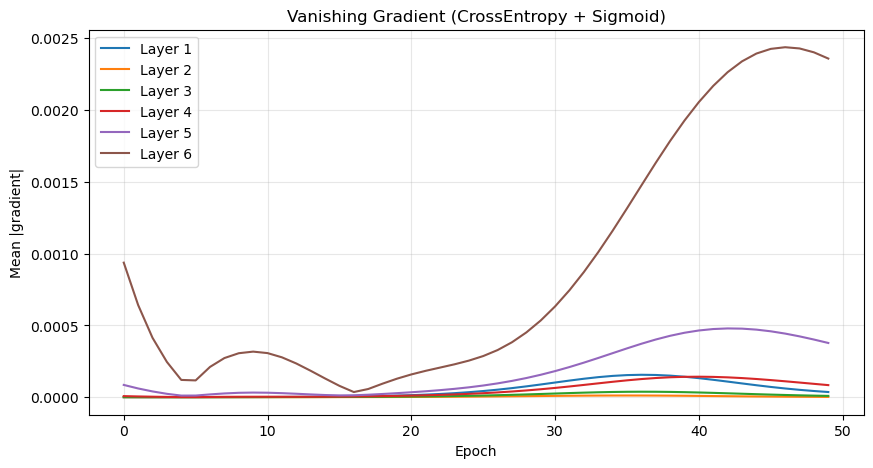

In [112]:
plt.figure(figsize=(10, 5))
for i, h in enumerate(history_ce):
    plt.plot(h, label=f"Layer {i+1}")
plt.xlabel("Epoch"); plt.ylabel("Mean |gradient|")
plt.title("Vanishing Gradient (CrossEntropy + Sigmoid)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Part 2: Mean Squared Error (MSE) with One-Hot Encoding
Unlike CrossEntropy which cleanly maps integer labels to log-probabilities, Mean Squared Error (MSE) expects the targets to be raw float numbers. To train a classifier with MSE, we must format our target labels as **One-Hot Encoded** binary float vectors (e.g., `Class 0 -> [1.0, 0.0, 0.0]`).

### 1. Data - Transform to One-Hot Encoding
**Description:** 
This cell takes our previously generated integer labels (`y_train`, `y_test`) and transforms them using PyTorch's `F.one_hot()`. It converts the $1$-dimensional target array into a $2$-dimensional matrix of shape `(N, 3)`, filled with floating-point zeros and ones.

In [113]:
num_classes = 3
y_train_oh = F.one_hot(y_train, num_classes=num_classes).float()
y_test_oh  = F.one_hot(y_test,  num_classes=num_classes).float()

print("One-hot encoded targets (first 3 rows):")
for i in range(3):
    print(f"  Class {y_train[i].item()} -> {y_train_oh[i].numpy().tolist()}")

One-hot encoded targets (first 3 rows):
  Class 0 -> [1.0, 0.0, 0.0]
  Class 0 -> [1.0, 0.0, 0.0]
  Class 1 -> [0.0, 1.0, 0.0]


### 2. Model - Initialize Modified MSE Architecture
**Description:** 
This is the exact same 6-layer `DeepNet` architecture as before, but with one critical change: the final output layer is now wrapped in a `torch.sigmoid()` activation. 

Because our target labels are now One-Hot encoded vectors of exactly $0.0$ and $1.0$, our network's predictions must mathematically fall within that exact $[0, 1]$ bounding range for the MSE loss to compute a stable error distance. Sigmoid enforces this bound.

In [114]:
class DeepNetMSE(nn.Module):
    def __init__(self):
        super().__init__()
        sizes = [4, 256, 256, 128, 128, 64, 32]
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(sizes[i], sizes[i+1]) for i in range(len(sizes)-1)]
        )
        self.output_layer = nn.Linear(32, 3)

    def forward(self, x):
        for layer in self.hidden_layers:
            x = torch.sigmoid(layer(x))
        return torch.sigmoid(self.output_layer(x)) # Final sigmoid for MSE

model_mse = DeepNetMSE()
optimizer_mse = optim.Adam(model_mse.parameters(), lr=0.001)

### 3. Training Algorithm - Execute Backpropagation
### 4. Loss Function and Activation Function - Describe and Visualize Loss
**Description:** 
We repeat the exact same `NUM_EPOCHS` training loop, but substitute the objective function with `nn.MSELoss()`. MSE simply takes the squared difference between our predicted $3$-dimensional float vector and the true One-Hot float vector. Just like before, we track the gradient magnitudes as they flow backwards through the network.

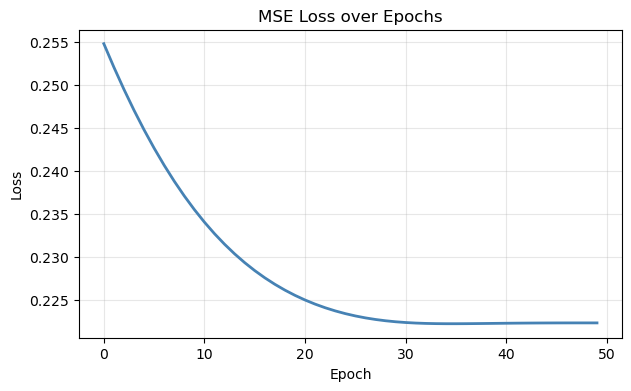

In [115]:
criterion_mse = nn.MSELoss()
history_mse = [[] for _ in model_mse.hidden_layers]
loss_history_mse = []

for epoch in range(1, NUM_EPOCHS + 1):
    optimizer_mse.zero_grad()
    
    outputs_mse = model_mse(X_train)
    loss_mse = criterion_mse(outputs_mse, y_train_oh)
    loss_mse.backward()

    for i, layer in enumerate(model_mse.hidden_layers):
        history_mse[i].append(layer.weight.grad.abs().mean().item())

    optimizer_mse.step()
    loss_history_mse.append(loss_mse.item())

# Visualize Loss
plt.figure(figsize=(7, 4))
plt.plot(loss_history_mse, color="steelblue", linewidth=2)
plt.title("MSE Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

### 5. Visualize the Vanishing Gradient
**Description:** 
This graph visualizes the gradient decay for the MSE model. Because the MSE loss gradient relies on a pure squared distance rather than a logarithm, its initial error signal is much weaker than CrossEntropy. As a result, the vanishing gradient problem is significantly exacerbated here.

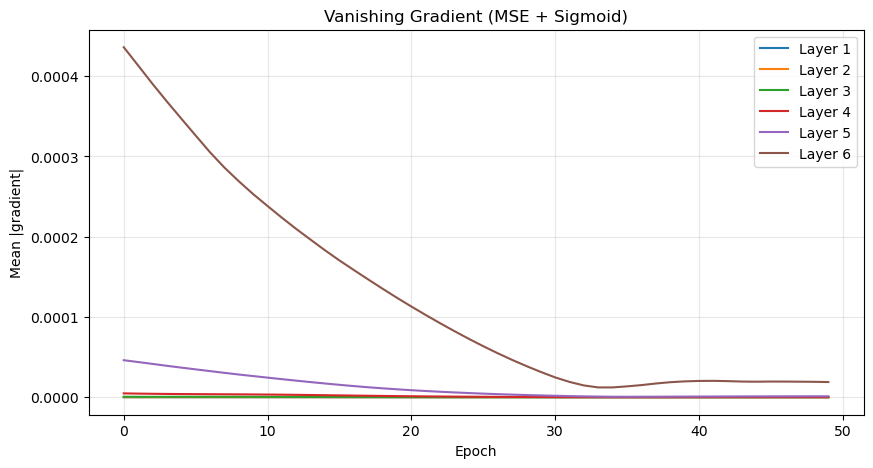

In [116]:
plt.figure(figsize=(10, 5))
for i, h in enumerate(history_mse):
    plt.plot(h, label=f"Layer {i+1}")
plt.xlabel("Epoch"); plt.ylabel("Mean |gradient|")
plt.title("Vanishing Gradient (MSE + Sigmoid)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 6. Comprehensive Comparison & Visualization
**Description:** 
To definitively conclude the experiment, this cell evaluates both networks sequentially and plots three critical metrics side-by-side:
1. **Normalized Loss Convergence:** Proves which loss function allows the network to learn faster.
2. **Gradient Magnitude (Log Scale):** Shows a direct mathematical comparison of the absolute gradient size reaching Layer 1 (Deepest) vs Layer 6 (Output).
3. **Final Test Accuracy:** Shows the tangible impact of the vanishing gradient on the model's actual predictive capability.

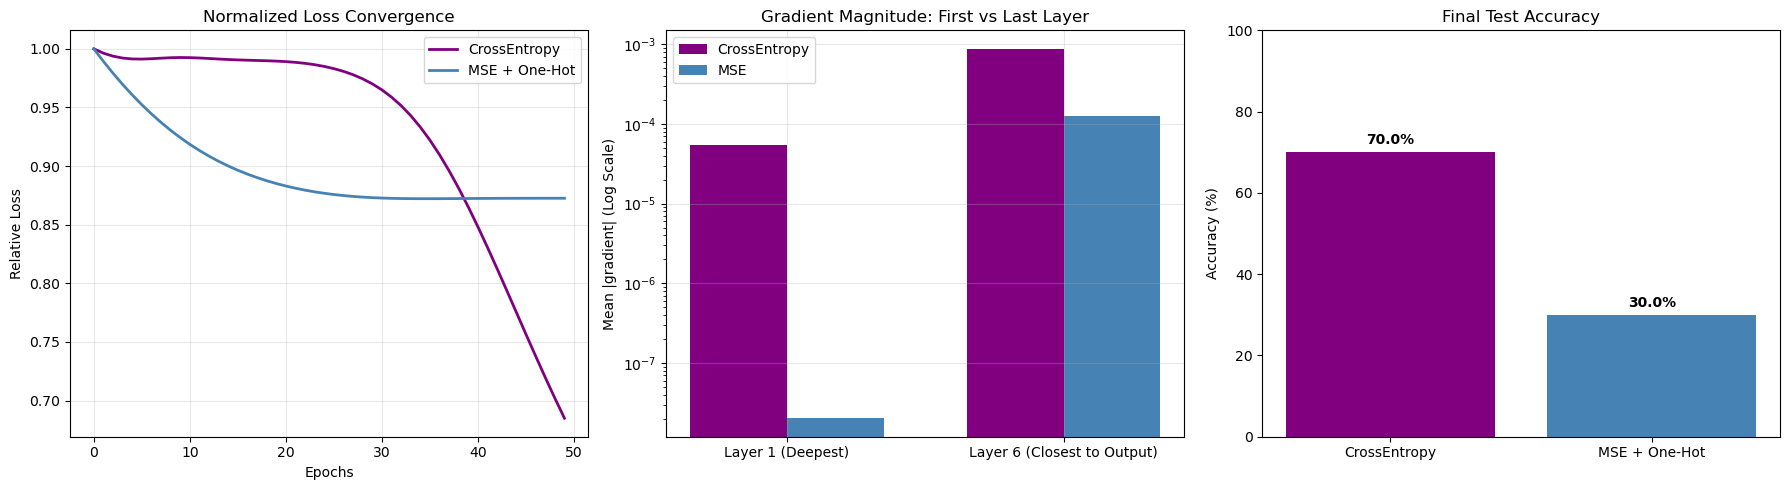

CrossEntropy achieves 70.0% accuracy, 
 demonstrating a much stronger and healthier gradient signal.
MSE+OneHot achieves 30.0% accuracy, 
 proving it struggles significantly more with the vanishing gradient problem.


In [118]:
import numpy as np

with torch.no_grad():
    preds_ce = model(X_test).argmax(dim=1)
    acc_ce = (preds_ce == y_test).float().mean() * 100
    
    preds_mse = model_mse(X_test).argmax(dim=1)
    acc_mse = (preds_mse == y_test).float().mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Loss Convergence Comparison (Normalized)
# We normalize the loss to a 0-1 scale to compare their decay shapes
norm_ce = np.array(loss_history_ce) / max(loss_history_ce)
norm_mse = np.array(loss_history_mse) / max(loss_history_mse)

axes[0].plot(norm_ce, label="CrossEntropy", color="purple", linewidth=2)
axes[0].plot(norm_mse, label="MSE + One-Hot", color="steelblue", linewidth=2)
axes[0].set_title("Normalized Loss Convergence")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Relative Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Gradient Decay Intensity
# We compare the average gradient magnitude of Layer 1 vs Output Layer
# to see which loss function causes worse vanishing gradients
layer1_ce_avg = np.mean(history_ce[0])
layer6_ce_avg = np.mean(history_ce[-1])

layer1_mse_avg = np.mean(history_mse[0])
layer6_mse_avg = np.mean(history_mse[-1])

bar_width = 0.35
x = np.arange(2)

axes[1].bar(x - bar_width/2, [layer1_ce_avg, layer6_ce_avg], bar_width, label='CrossEntropy', color='purple')
axes[1].bar(x + bar_width/2, [layer1_mse_avg, layer6_mse_avg], bar_width, label='MSE', color='steelblue')
axes[1].set_title("Gradient Magnitude: First vs Last Layer")
axes[1].set_xticks(x)
axes[1].set_xticklabels(["Layer 1 (Deepest)", "Layer 6 (Closest to Output)"])
axes[1].set_yscale('log') # Log scale because layer 1 is tiny!
axes[1].set_ylabel("Mean |gradient| (Log Scale)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Final Accuracy
axes[2].bar(["CrossEntropy", "MSE + One-Hot"], [acc_ce.item(), acc_mse.item()], color=["purple", "steelblue"])
axes[2].set_title("Final Test Accuracy")
axes[2].set_ylabel("Accuracy (%)")
axes[2].set_ylim(0, 100)
for i, v in enumerate([acc_ce.item(), acc_mse.item()]):
    axes[2].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"CrossEntropy achieves {acc_ce:.1f}% accuracy, \n demonstrating a much stronger and healthier gradient signal.")
print(f"MSE+OneHot achieves {acc_mse:.1f}% accuracy, \n proving it struggles significantly more with the vanishing gradient problem.")